# Прогнозирование тяжести авиационных происшествий
(примечание: текст к проекту может быть сыроват, поэтому планируется доработать его до 28 февраля, по возможности)




# Цель проекта

Основная цель проекта — разработать модель машинного обучения, способную прогнозировать степень повреждения воздушного судна на основе технических характеристик самолёта и обстоятельств инцидента.

# 1. Установка библиотек

In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from IPython.display import display as ipy_display, HTML
from babel.util import missing
from networkx.drawing import display
from numba.core.types import int64
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    average_precision_score,
    precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight
import warnings
from sklearn.preprocessing import LabelEncoder
warnings.filterwarnings('ignore', category=FutureWarning)

pd.options.display.html.table_schema = False

# 2. Описание датасета

2.1.
Датасет содержит информацию об авиационных инцидентах и происшествиях.
Каждая строка представляет отдельный инцидент и включает сведения о характеристиках воздушного судна, условиях полёта и последствиях события.

Всего в датасете:

23 519 наблюдений

23 признака

Incident_Date — дата инцидента.

Aircaft_Model — модель самолёта, участвовавшего в инциденте.

Aircaft_Registration — регистрационный номер воздушного судна.

Aircaft_Operator — авиакомпания или организация-оператор.

Aircaft_Nature — тип рейса (коммерческий, военный, частный, грузовой и др.).

Incident_Category — категория происшествия (авария, отказ, угон, столкновение и т.д.).

Incident_Cause(es) — основная причина инцидента (технический отказ, ошибка пилота, погодные условия и др.).

Incident_Location — место происшествия (страна, регион или город).

Aircaft_Damage_Type — степень повреждения самолёта (Minor, Substantial, Destroyed и др.).

Date — альтернативное представление даты события (требует проверки на дублирование с Incident_Date).

Time — время происшествия.

Arit — дополнительный технический признак (требует уточнения значения).

Aircaft_Engines — количество двигателей самолёта.

Onboard_Crew — количество членов экипажа на борту.

Onboard_Passengers — количество пассажиров на борту.

Onboard_Total — общее количество людей на борту (экипаж + пассажиры).

Fatalities — количество погибших в результате инцидента.

Aircaft_First_Flight — дата первого полёта самолёта (может использоваться для расчёта возраста самолёта).

Aircraft_Phase — фаза полёта, во время которой произошёл инцидент (взлёт, посадка, крейсерский полёт и др.).

Departure_Airport — аэропорт вылета.

Destination_Airport — аэропорт назначения.

Ground_Casualties — количество пострадавших на земле.

Collision_Casualties — количество пострадавших в результате столкновения.

In [224]:
df = pd.read_csv("Aircraft_Incident_Dataset.csv")
print(df.shape)
print(df.info())

ipy_display(df)

(23519, 23)
<class 'pandas.DataFrame'>
RangeIndex: 23519 entries, 0 to 23518
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Incident_Date         23519 non-null  str  
 1   Aircaft_Model         23519 non-null  str  
 2   Aircaft_Registration  21958 non-null  str  
 3   Aircaft_Operator      23519 non-null  str  
 4   Aircaft_Nature        23519 non-null  str  
 5   Incident_Category     23519 non-null  str  
 6   Incident_Cause(es)    23519 non-null  str  
 7   Incident_Location     22587 non-null  str  
 8   Aircaft_Damage_Type   22751 non-null  str  
 9   Date                  23519 non-null  str  
 10  Time                  9203 non-null   str  
 11  Arit                  23519 non-null  str  
 12  Aircaft_Engines       10636 non-null  str  
 13  Onboard_Crew          23519 non-null  str  
 14  Onboard_Passengers    23519 non-null  str  
 15  Onboard_Total         23519 non-null  str  
 16  Fat

,Incident_Date,Aircaft_Model,Aircaft_Registration,Aircaft_Operator,Aircaft_Nature,Incident_Category,Incident_Cause(es),Incident_Location,Aircaft_Damage_Type,Date,Time,Arit,Aircaft_Engines,Onboard_Crew,Onboard_Passengers,Onboard_Total,Fatalities,Aircaft_First_Flight,Aircraft_Phase,Departure_Airport,Destination_Airport,Ground_Casualties,Collision_Casualties
0,03-JAN-2022,British Aerospace 4121 Jetstream 41,ZS-NRJ,SA Airlink,Domestic Non Scheduled Passenger,Accident | repairable-damage,"Airplane - Engines, Airplane - Engines - Prop/...",near Venetia Mine...,Substantial,Monday 3 January 2022,08:10,03-JAN-2022,2 Garrett TPE331-14GR-805H,Fatalities: 0 / Occupants: 3,Fatalities: 0 / Occupants: 4,Fatalities: 0 / Occupants: 7,0,1995-05-19 (26 years 8 months),Landing (LDG),Johannesburg-O.R. Tambo International Airport ...,"Venetia Mine Airport (FAVM) , South Africa",NaN,NaN
1,04-JAN-2022,British Aerospace 3101 Jetstream 31,HR-AYY,LANHSA,Domestic Scheduled Passenger,Accident | repairable-damage,"Airplane - Undercarriage, Airplane - Undercarr...",Roatán-Juan ...,Substantial,Tuesday 4 January 2022,ca 12:00,04-JAN-2022,NaN,Fatalities: 0 / Occupants:,Fatalities: 0 / Occupants:,Fatalities: 0 / Occupants: 19,0,1985,Landing (LDG),La Ceiba-Goloson International Airport (LCE/MH...,Roatán-Juan Manuel Gálvez International Airpor...,NaN,NaN
2,05-JAN-2022,Boeing 737-4H6,EP-CAP,Caspian Airlines,Domestic Scheduled Passenger,Accident | repairable-damage,"Airplane - Undercarriage, Airplane - Undercarr...",Isfahan-Shah...,Substantial,Wednesday 5 January 2022,17:07,05-JAN-2022,2 CFMI CFM56-3C1,Fatalities: 0 / Occupants:,Fatalities: 0 / Occupants:,Fatalities: 0 / Occupants: 116,0,1992-09-18 (29 years 4 months),Landing (LDG),"Mashhad Airport (MHD/OIMM) , Iran","Isfahan-Shahid Beheshti Airport (IFN/OIFM) , Iran",NaN,NaN
3,08-JAN-2022,Tupolev Tu-204-100C,RA-64032,"Cainiao, opb Aviastar-TU",Cargo,Accident | hull-loss,"Cargo - Fire/smoke, Result - Damaged on the gr...",Hangzhou-Xia...,Destroyed,Saturday 8 January 2022,04:40,08-JAN-2022,2 Soloviev PS-90A,Fatalities: 0 / Occupants: 8,Fatalities: 0 / Occupants: 0,Fatalities: 0 / Occupants: 8,0,2002-07-18 (19 years 6 months),Standing (STD),Hangzhou-Xiaoshan International Airport (HGH/Z...,"Novosibirsk-Tolmachevo Airport (OVB/UNNT) , Ru...",NaN,NaN
4,12-JAN-2022,Beechcraft 200 Super King Air,NaN,private,Illegal Flight,"Criminal occurrence (sabotage, shoot down) | h...",Result - Damaged on the ground,"Machakilha, ...",Damaged beyond repair,Wednesday 12 January 2022,c. 02:00,12-JAN-2022,NaN,Fatalities: 0 / Occupants: 0,Fatalities: 0 / Occupants: 0,Fatalities: 0 / Occupants: 0,0,NaN,Standing (STD),?,?,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23514,25-FEB-1920,Handley Page O/400,G-EAMC,Handley Page Transport,Unknown,Accident | hull-loss,"Result - Emergency, forced landing - Outside a...",near El Shereik,Damaged beyond repair,Wednesday 25 February 1920,NaN,25-FEB-1920,NaN,Fatalities: 0 / Occupants: 4,Fatalities: 0 / Occupants: 0,Fatalities: 0 / Occupants: 4,0,NaN,Unknown (UNK),"Aswan Airport (ASW/HESN) , Egypt","Khartoum-Civil Airport (KRT/HSSS) , Sudan",NaN,NaN
23515,30-JUN-1920,Handley Page O/400,G-EAKE,Handley Page Transport,Demonstration,Accident | hull-loss,"Result - Emergency, forced landing - Outside a...",Östanå,Damaged beyond repair,Wednesday 30 June 1920,NaN,30-JUN-1920,NaN,Fatalities: 0 / Occupants: 2,Fatalities: 0 / Occupants: 0,Fatalities: 0 / Occupants: 2,0,1919,En route (ENR),"Stockholm (unknown airport) , Sweden","Kjeller Air Base (ENKJ) , Norway",NaN,NaN
23516,14-DEC-1920,Handley Page O/400,G-EAMA,Handley Page Transport,International Scheduled Passenger,Accident | hull-loss,Result - CFIT - Level ground,Golders Green,Damaged beyond repair,Tuesday 14 December 1920,ca 12:15,14-DEC-1920,NaN,Fatalities: 2 / Occupants: 2,Fatalities: 2 / Occupants: 6,Fatalities: 4 / Occupants: 8,4,NaN,Initial climb (ICL),"London-Cricklewood Aerodrome , United Kingdom

# 3. Анализ дубликатов

Датасет содержит 109 полных дубликатов, что составляет 0,46% от всего датасета. Был проведен частичный анализ этих дубликатов, предполагаемая причина их - это Incident_Date (т.к. может быть абсолютно один и тот же самолет, но с неизвестной датой, написанной в виде ??-???-{год}). Также был проведен анализ неполных дубликатов, но их было решено оставить, а полные дубликаты убрать.

In [225]:
print(df.duplicated().sum())
full_duplicates = df[df.duplicated()]
full_duplicates.head(10)

109


,Incident_Date,Aircaft_Model,Aircaft_Registration,Aircaft_Operator,Aircaft_Nature,Incident_Category,Incident_Cause(es),Incident_Location,Aircaft_Damage_Type,Date,Time,Arit,Aircaft_Engines,Onboard_Crew,Onboard_Passengers,Onboard_Total,Fatalities,Aircaft_First_Flight,Aircraft_Phase,Departure_Airport,Destination_Airport,Ground_Casualties,Collision_Casualties
16111,14-OCT-1954,Grumman SA-16 Albatross,NaN,USAF,Military,"other occurrence (ground fire, sabotage) | hul...","Fire - Hangar, ground fire, Result - Damaged o...",Goose Bay Ai...,Damaged beyond repair,Thursday 14 October 1954,NaN,14-OCT-1954,NaN,Fatalities: 0 / Occupants: 0,Fatalities: 0 / Occupants: 0,Fatalities: 0 / Occupants: 0,0,NaN,Standing (STD),-,-,NaN,NaN
17513,25-MAR-1948,Douglas C-54 (DC-4),NaN,USAF,-,"other occurrence (ground fire, sabotage) | hul...",Result - Damaged on the ground,Oklahoma Cit...,Damaged beyond repair,Thursday 25 March 1948,18:00,25-MAR-1948,NaN,Fatalities: 0 / Occupants: 0,Fatalities: 0 / Occupants: 0,Fatalities: 0 / Occupants: 0,0,NaN,Standing (STD),-,-,NaN,NaN
17563,03-JUN-1948,Douglas C-47 (DC-3),NaN,Royal Egyptian Air Force,Military,"Criminal occurrence (sabotage, shoot down) | h...","Security - Shot, Security - Shot - Air-to-air",NaN,Damaged beyond repair,Thursday 3 June 1948,NaN,03-JUN-1948,NaN,Fatalities: / Occupants:,Fatalities: / Occupants:,Fatalities: / Occupants:,0,NaN,En route (ENR),?,?,NaN,NaN
20830,18-SEP-1944,Junkers Ju-52/3m,NaN,German AF,Military,Accident | hull-loss,Info-Unavailable,Eindhoven Ai...,Damaged beyond repair,Monday 18 September 1944,NaN,18-SEP-1944,NaN,Fatalities: / Occupants:,Fatalities: / Occupants:,Fatalities: / Occupants:,0,NaN,Unknown (UNK),?,?,NaN,NaN
22515,??-???-1942,Junkers Ju-52/3mge,NaN,German AF,Military,Accident | hull-loss,Info-Unavailable,NaN,Damaged beyond repair,xx xxx 1942,NaN,??-???-1942,NaN,Fatalities: / Occupants:,Fatalities: / Occupants:,Fatalities: / Occupants:,0,NaN,Unknown (UNK),?,?,NaN,NaN
22517,??-???-1942,Junkers Ju-52/3mge,NaN,German AF,Military,Accident | hull-loss,Info-Unavailable,NaN,Damaged beyond repair,xx xxx 1942,NaN,??-???-1942,NaN,Fatalities: / Occupants:,Fatalities: / Occupants:,Fatalities: / Occupants:,0,NaN,Unknown (UNK),?,?,NaN,NaN
22518,??-???-1942,Junkers Ju-52/3mfe,NaN,German AF,Military,Accident | hull-loss,Info-Unavailable,NaN,Damaged beyond repair,xx xxx 1942,NaN,??-???-1942,NaN,Fatalities: / Occupants:,Fatalities: / Occupants:,Fatalities: / Occupants:,0,NaN,Unknown (UNK),?,?,NaN,NaN
22712,08-DEC-1941,Curtiss AT-32A Condor II,NaN,CNAC,-,"Criminal occurrence (sabotage, shoot down) | h...","Result - Damaged on the ground, Security - Des...",Hong Kong-Ka...,Damaged beyond repair,Monday 8 December 1941,ca 08:00,08-DEC-1941,NaN,Fatalities: 0 / Occupants: 0,Fatalities: 0 / Occupants: 0,Fatalities: 0 / Occupants: 0,0,NaN,Standing (STD),-,-,NaN,NaN
22717,08-DEC-1941,Curtiss AT-32D Condor II,NaN,CNAC,-,"Criminal occurrence (sabotage, shoot down) | h...","Result - Damaged on the ground, Security - Des...",Hong Kong-Ka...,Damaged beyond repair,Monday 8 December 1941,ca 08:00,08-DEC-1941,NaN,Fatalities: 0 / Occupants: 0,Fatalities: 0 / Occupants: 0,Fatalities: 0 / Occupants: 0,0,NaN,Standing (STD),-,-,NaN,NaN
22741,??-???-1941,Junkers Ju-52/3mfe,NaN,German AF,Military,Accident | hull-loss,Info-Unavailable,Creta,Damaged beyond repair,xx xxx 1941,NaN,??-???-1941,NaN,Fatalities: / Occupants:,Fatalities: / Occupants:,Fatalities: / Occupants:,0,NaN,Unknown (UNK),?,?,NaN,NaN


In [226]:
percent_of_duplicates = df.duplicated().sum()/int(df.shape[0])*100
print(f"Процент дубликатов в файле: {percent_of_duplicates.round(2)}%")

Процент дубликатов в файле: 0.46%


In [227]:
key_cols = [
    'Incident_Category',
    'Incident_Cause(es)',
    'Aircaft_Model',
    'Fatalities',
    'Incident_Location',
    'Aircaft_Operator',
    'Aircaft_Nature',
    'Aircaft_Registration'

]

print(df.duplicated(subset=key_cols, keep = False).sum())

267


In [228]:
df_duplicats_1 = df[df.duplicated(subset=key_cols, keep = False)]
df_duplicats_1.head(10)

,Incident_Date,Aircaft_Model,Aircaft_Registration,Aircaft_Operator,Aircaft_Nature,Incident_Category,Incident_Cause(es),Incident_Location,Aircaft_Damage_Type,Date,Time,Arit,Aircaft_Engines,Onboard_Crew,Onboard_Passengers,Onboard_Total,Fatalities,Aircaft_First_Flight,Aircraft_Phase,Departure_Airport,Destination_Airport,Ground_Casualties,Collision_Casualties
5835,09-FEB-1994,Boeing 737-260 Advanced,ET-AJB,Ethiopian Airlines,Domestic Scheduled Passenger,Hijacking | repairable-damage,Result - Hijacking - Peaceful surrender / arre...,Djibouti Air...,NaN,Wednesday 9 February 1994,NaN,09-FEB-1994,2 Pratt Whitney JT8D-17A,Fatalities: 0 / Occupants: 8,Fatalities: 0 / Occupants: 115,Fatalities: 0 / Occupants: 123,0,1988-07-07 (5 years 7 months),En route (ENR),"Bahar Dar Airport (BJR/HABD) , Ethiopia","Addis Ababa-Bole Airport (ADD/HAAB) , Ethiopia",NaN,NaN
6084,23-JAN-1993,Lockheed L-100-30 Hercules,D2-EHD,"Transafrik, opf Endiama",Cargo,"Criminal occurrence (sabotage, shoot down) | r...","Result - Emergency, forced landing - On runway...",near Luena Airpor...,Substantial,Saturday 23 January 1993,NaN,23-JAN-1993,4 Allison 501-D22A,Fatalities: 0 / Occupants:,Fatalities: 0 / Occupants:,Fatalities: 0 / Occupants:,0,1980,Initial climb (ICL),"Luena Airport (LUO/FNUE) , Angola",?,NaN,NaN
6282,29-OCT-1993,Antonov An-2,LZ-...,Unknown,Unknown,Accident | hull-loss,Info-Unavailable,within Bulgaria,Damaged beyond repair,Friday 29 October 1993,NaN,29-OCT-1993,NaN,Fatalities: 1 / Occupants:,Fatalities: 0 / Occupants:,Fatalities: 1 / Occupants:,1,NaN,Unknown (UNK),?,?,NaN,NaN
6294,12-NOV-1993,McDonnell Douglas DC-9-82 (MD-82),B-2138,China Northern,Domestic Scheduled Passenger,Hijacking | repairable-damage,Result - Hijacking - Peaceful surrender / arre...,Taipei,NaN,Friday 12 November 1993,NaN,12-NOV-1993,2 Pratt Whitney JT8D-217A,Fatalities: 0 / Occupants: 9,Fatalities: 0 / Occupants: 73,Fatalities: 0 / Occupants: 82,0,1990,En route (ENR),"Changchun Airport (CGQ/ZYRD) , China","Fuzhou Yixu Airport (FOC/ZSFZ) , China",NaN,NaN
6317,08-DEC-1993,McDonnell Douglas DC-9-82 (MD-82),B-2138,China Northern,Domestic Scheduled Passenger,Hijacking | repairable-damage,Result - Hijacking - Peaceful surrender / arre...,Taipei,NaN,Wednesday 8 December 1993,NaN,08-DEC-1993,2 Pratt Whitney JT8D-217A,Fatalities: 0 / Occupants: 8,Fatalities: 0 / Occupants: 129,Fatalities: 0 / Occupants: 137,0,1990,En route (ENR),"Qingdao Airport (TAO/ZSQD) , China","Fuzhou Yixu Airport (FOC/ZSFZ) , China",NaN,NaN
6578,13-NOV-1992,Douglas C-47 (DC-3),NaN,Mexican AF,Military,occurrence unknown | hull-loss,Info-Unavailable,NaN,Damaged beyond repair,Friday 13 November 1992,NaN,13-NOV-1992,NaN,Fatalities: / Occupants:,Fatalities: / Occupants:,Fatalities: / Occupants:,0,NaN,Unknown (UNK),?,?,NaN,NaN
6837,25-NOV-1991,Boeing 737-260 Advanced,ET-AJB,Ethiopian Airlines,Domestic Scheduled Passenger,Hijacking | repairable-damage,Result - Hijacking - Peaceful surrender / arre...,Djibouti Air...,NaN,Monday 25 November 1991,NaN,25-NOV-1991,2 Pratt Whitney JT8D-17A,Fatalities: 0 / Occupants: 6,Fatalities: 0 / Occupants: 85,Fatalities: 0 / Occupants: 91,0,1988-07-07 (3 years 5 months),En route (ENR),"Addis Ababa-Bole Airport (ADD/HAAB) , Ethiopia",Dire Dawa-Aba Tenna D Yilma Airport (DIR/HADR)...,NaN,NaN
6976,08-JUN-1990,Tupolev Tu-154,NaN,Aeroflot,Domestic Scheduled Passenger,Hijacking | repairable-damage,Result - Hijacking - Peaceful surrender / arre...,Stockholm-Ar...,NaN,Friday 8 June 1990,NaN,08-JUN-1990,NaN,Fatalities: 0 / Occupants: 7,Fatalities: 0 / Occupants: 114,Fatalities: 0 / Occupants: 121,0,NaN,En route (ENR),"Minsk-2 International Airport (MSQ/UMMS) , Bel...","Murmansk Airport (MMK/ULMM) , Russia",NaN,NaN
6983,24-JUN-1990,Tupolev Tu-134,NaN,Aeroflot,Domestic Scheduled Passenger,Hijacking | repairable-damage,Result - Hijacking - Peaceful surrender / arre...,Helsinki-Van...,NaN,Sunday 24 June 1990,NaN,24-JUN-1990,NaN,Fatalities: 0 / Occupants: 6,Fatalities: 0 / Occupants: 70,Fatalities: 0 / Oc

In [229]:
df.columns = df.columns.str.strip()
print("До:", df.shape)

df = df.drop_duplicates()

print("После:", df.shape)


До: (23519, 23)
После: (23410, 23)


# 4. Анализ пропусков

По предварительным данным, наибольшее число пропусков было в Ground_Casualties и Collision_Casualties, поэтому впервую очередь было принято решение проанализировать их

In [230]:
missing = df.isnull().sum()
print(missing[missing>0])

Aircaft_Registration     1452
Incident_Location         916
Aircaft_Damage_Type       768
Time                    14210
Aircaft_Engines         12774
Aircaft_First_Flight     5379
Ground_Casualties       23063
Collision_Casualties    23118
dtype: int64


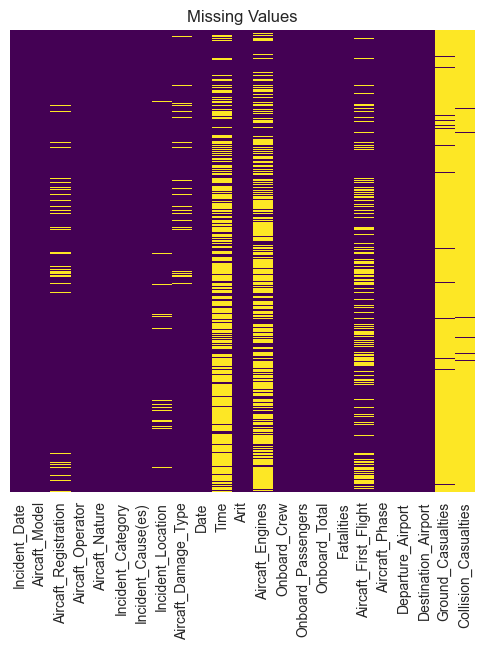

In [231]:
plt.figure(figsize=(6, 6))

sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values")
plt.show()

# 4.1. Работа с Ground_Casualties и Collision_Casualties

Изучаем уникальныые значения в каждой из этих категорий

In [232]:
temp_ground = df['Ground_Casualties'].fillna(0)
print(df['Ground_Casualties'].dropna().unique())
print(df['Collision_Casualties'].dropna().unique())

<StringArray>
['Fatalities: 3', 'Fatalities: 1', 'Fatalities: 2', 'Fatalities: 14', 'Fatalities: 6', 'Fatalities: 35', 'Fatalities: 17', 'Fatalities: 8', 'Fatalities: 10', 'Fatalities: 4', 'Fatalities: 25', 'Fatalities: 37', 'Fatalities: 7', 'Fatalities: 12', 'Fatalities: 28', 'Fatalities: 49', 'Fatalities: 13', 'Fatalities: 30', 'Fatalities: 1600', 'Fatalities: 900', 'Fatalities: 125', 'Fatalities: 5', 'Fatalities: 45', 'Fatalities: 237', 'Fatalities: 18', 'Fatalities: 23', 'Fatalities: 39', 'Fatalities: 24', 'Fatalities: 22', 'Fatalities: 11', 'Fatalities: 44', 'Fatalities: 15', 'Fatalities: 9', 'Fatalities: 32', 'Fatalities: 88', 'Fatalities: 19', 'Fatalities: 71', 'Fatalities: 107', 'Fatalities: 87']
Length: 39, dtype: str
<StringArray>
['Fatalities: 1', 'Fatalities: 5', 'Fatalities: 2', 'Fatalities: 4', 'Fatalities: 3', 'Fatalities: 154', 'Fatalities: 69', 'Fatalities: 6', 'Fatalities: 110', 'Fatalities: 9', 'Fatalities: 24', 'Fatalities: 8', 'Fatalities: 37', 'Fatalities: 312', '

Убираем Fatalities и оставляем только цифры

In [233]:
df['Ground_Casualties_Num'] = df['Ground_Casualties'].str.extract(r'(\d+)').astype(float)
df['Collision_Casualties_Num'] = df['Collision_Casualties'].str.extract(r'(\d+)').astype(float)
df['Ground_Casualties_Num'] = df['Ground_Casualties_Num'].fillna(0).astype(int)
df['Collision_Casualties_Num'] = df['Collision_Casualties_Num'].fillna(0).astype(int)
print(df[['Ground_Casualties_Num', 'Collision_Casualties_Num']].describe())

       Ground_Casualties_Num  Collision_Casualties_Num
count           23410.000000              23410.000000
mean                0.211192                  0.164673
std                12.233611                  4.224408
min                 0.000000                  0.000000
25%                 0.000000                  0.000000
50%                 0.000000                  0.000000
75%                 0.000000                  0.000000
max              1600.000000                335.000000


Здесь мы создаем новую переменную Lethality_Rate, которая показывает долю жертв на число состава самолета

In [234]:
onboard_extracted = df['Onboard_Total'].str.extract(r'Fatalities:\s*(\d+)\s*/\s*Occupants:\s*(\d+)')
print(onboard_extracted)
df['Onboard_Fatalities'] = onboard_extracted[0].fillna(0).astype(int)
df['Onboard_Occupants'] = onboard_extracted[1].fillna(0).astype(int)
df['Lethality_Rate'] = df['Onboard_Fatalities'] / df['Onboard_Occupants'].replace(0, 1)

        0    1
0       0    7
1       0   19
2       0  116
3       0    8
4       0    0
...    ..  ...
23514   0    4
23515   0    2
23516   4    8
23517  14   14
23518   1    7

[23410 rows x 2 columns]


Тут были изучены самые большое число Ground_Casualties, благодаря чему были найдены следующие аномалии: 3 столбец таблицы показывает случай, когда при больших Ground_Casualties, Fatalities среди экипажа равны 0; 10 столбец таблицы показывает, что Destroyed не всегда означает, что весь экипаж погиб (100 жертв и 117 пассажировов => 17 выживших)

,Incident_Date,Aircaft_Model,Ground_Casualties_Num,Aircaft_Nature,Aircaft_Damage_Type,Onboard_Total,Collision_Casualties_Num,Incident_Cause(es),Aircraft_Phase,Fatalities
4280,11-SEP-2001,Boeing 767-223ER,1600,Domestic Scheduled Passenger,Destroyed,Fatalities: 92 / Occupants: 92,0,"Security - Hijack, Security - Suicide",En route (ENR),1692
4281,11-SEP-2001,Boeing 767-222,900,Domestic Scheduled Passenger,Destroyed,Fatalities: 65 / Occupants: 65,0,"Security - Hijack, Security - Suicide",En route (ENR),965
5298,08-JAN-1996,Antonov An-32B,237,Cargo,Damaged beyond repair,Fatalities: 0 / Occupants: 6,0,Result - Runway excursion,Initial climb (ICL),237
4283,11-SEP-2001,Boeing 757-223,125,Domestic Scheduled Passenger,Destroyed,Fatalities: 64 / Occupants: 64,0,"Security - Hijack, Security - Suicide",En route (ENR),189
13424,24-DEC-1966,Canadair CL-44D4-1,107,Cargo,Destroyed,Fatalities: 4 / Occupants: 4,0,Info-Unavailable,Approach (APR),111
10390,13-OCT-1976,Boeing 707-131F,88,Cargo,Destroyed,Fatalities: 3 / Occupants: 3,0,"Flightcrew - Insufficient rest / fatigue, Resu...",Initial climb (ICL),91
13952,01-FEB-1963,Vickers 754D Viscount,87,International Scheduled Passenger,Destroyed,Fatalities: 14 / Occupants: 14,3,"ATC & navigation - VFR flight in IMC, Collisio...",Approach (APR),101
12307,16-MAR-1969,McDonnell Douglas DC-9-32,71,International Scheduled Passenger,Destroyed,Fatalities: 84 / Occupants: 84,0,"Collision - Object, Collision - Object - Mast/...",Initial climb (ICL),155
8416,18-SEP-1984,Douglas DC-8-55F,49,Cargo,Damaged beyond repair,Fatalities: 4 / Occupants: 4,0,"Collision - Object, Collision - Object - Appro...",Takeoff (TOF),53
3413,05-SEP-2005,Boeing 737-230,49,Domestic Scheduled Passenger,Destroyed,Fatalities: 100 / Occupants: 117,0,Landing/takeoff - Takeoff - Wrong takeoff conf...,Initial climb (ICL),149


<Axes: xlabel='Ground_Casualties_Num'>

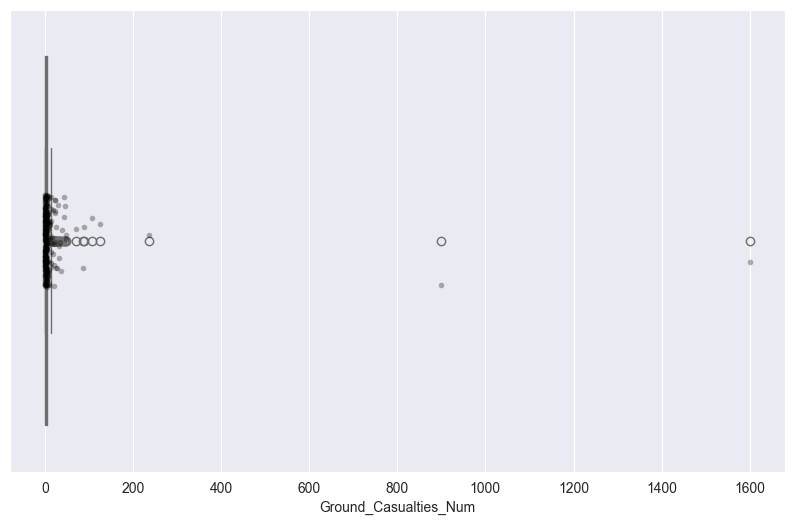

In [235]:
ipy_display(df.sort_values('Ground_Casualties_Num', ascending=False)[['Incident_Date', 'Aircaft_Model', 'Ground_Casualties_Num', "Aircaft_Nature", "Aircaft_Damage_Type", "Onboard_Total", "Collision_Casualties_Num", 'Incident_Cause(es)', "Aircraft_Phase", "Fatalities"]].head(10))
filtered_data = df[df['Ground_Casualties_Num'] > 0]
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_data, x='Ground_Casualties_Num', color='lightcoral')
sns.stripplot(data=filtered_data, x='Ground_Casualties_Num', color='black', alpha=0.3, size=4)

Здесь рассматриваются большие значения Collision_Casualties, которые тоже являются выбросами, однако в данном датасете их удалять нельзя, т.к. они в себе могут содержать важную информацию. К примеру, в этом случае была замечена аномалия: в 4 столбце при высоких показателях Collision_Casualties_Num,тип повреждения является Minor

,Incident_Date,Aircaft_Model,Collision_Casualties_Num,Aircaft_Nature,Aircaft_Damage_Type,Onboard_Total,Ground_Casualties_Num,Incident_Cause(es),Aircraft_Phase,Fatalities
9994,27-MAR-1977,Boeing 747-206B,335,Int'l Non Scheduled Passenger,Destroyed,Fatalities: 248 / Occupants: 248,0,"Collision - Aircraft, Collision - Aircraft - O...",Takeoff (TOF),248
5495,12-NOV-1996,Ilyushin Il-76TD,312,Cargo,Destroyed,Fatalities: 37 / Occupants: 37,0,"Collision - Aircraft, Collision - Aircraft - I...",En route (ENR),37
9993,27-MAR-1977,Boeing 747-121,248,Int'l Non Scheduled Passenger,Destroyed,Fatalities: 335 / Occupants: 396,0,"Collision - Aircraft, Collision - Aircraft - O...",Taxi (TXI),335
3207,29-SEP-2006,Embraer EMB-135BJ Legacy 600,154,Ferry/positioning,Minor,Fatalities: 0 / Occupants: 7,0,"Collision - Aircraft, Collision - Aircraft - I...",En route (ENR),0
10371,10-SEP-1976,Hawker Siddeley HS-121 Trident 3B,113,International Scheduled Passenger,Destroyed,Fatalities: 63 / Occupants: 63,0,"Collision - Aircraft, Collision - Aircraft - I...",En route (ENR),63
4302,08-OCT-2001,Cessna 525A CitationJet CJ2,110,Executive,Damaged beyond repair,Fatalities: 4 / Occupants: 4,0,"Collision - Aircraft, Collision - Aircraft - O...",Taxi (TXI),4
12410,23-JUN-1969,Ilyushin Il-14M,96,Domestic Scheduled Passenger,Damaged beyond repair,Fatalities: 24 / Occupants: 24,0,"Collision - Aircraft, Collision - Aircraft - I...",En route (ENR),24
9567,11-AUG-1979,Tupolev Tu-134A,94,Domestic Scheduled Passenger,Destroyed,Fatalities: 84 / Occupants: 84,0,"Collision - Aircraft, Collision - Aircraft - I...",En route (ENR),84
14819,16-DEC-1960,Lockheed L-1049 Super Constellation,84,Domestic Scheduled Passenger,Damaged beyond repair,Fatalities: 44 / Occupants: 44,0,"Collision - Aircraft, Collision - Aircraft - I...",Approach (APR),44
9566,11-AUG-1979,Tupolev Tu-134A,84,Domestic Scheduled Passenger,Destroyed,Fatalities: 94 / Occupants: 94,0,"Collision - Aircraft, Collision - Aircraft - I...",En route (ENR),94


<Axes: xlabel='Collision_Casualties_Num'>

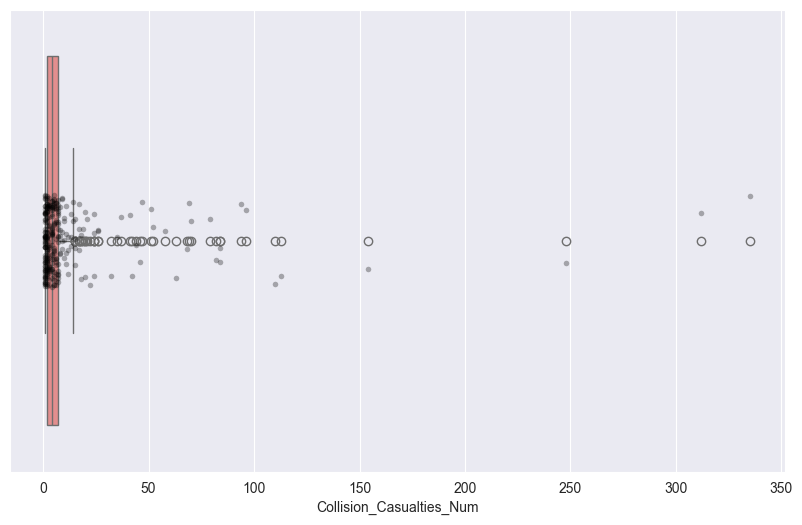

In [236]:
ipy_display(df.sort_values('Collision_Casualties_Num', ascending=False)[['Incident_Date', 'Aircaft_Model', 'Collision_Casualties_Num', "Aircaft_Nature", "Aircaft_Damage_Type", "Onboard_Total", "Ground_Casualties_Num", 'Incident_Cause(es)', "Aircraft_Phase", "Fatalities"]].head(10))
filtered_data = df[df['Collision_Casualties_Num'] > 0]
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_data, x='Collision_Casualties_Num', color='lightcoral')
sns.stripplot(data=filtered_data, x='Collision_Casualties_Num', color='black', alpha=0.3, size=4)

Проверяется гипотеза, что Fatalities = Fatalities_Onboard_Total + Ground_Casualties_Num + Collision_Casualties_Num

,Incident_Date,Aircaft_Model,Fatalities,Aircaft_Nature,Aircaft_Damage_Type,Onboard_Total,Ground_Casualties_Num,Incident_Cause(es),Aircraft_Phase,Collision_Casualties_Num
4280,11-SEP-2001,Boeing 767-223ER,1692,Domestic Scheduled Passenger,Destroyed,Fatalities: 92 / Occupants: 92,1600,"Security - Hijack, Security - Suicide",En route (ENR),0
4281,11-SEP-2001,Boeing 767-222,965,Domestic Scheduled Passenger,Destroyed,Fatalities: 65 / Occupants: 65,900,"Security - Hijack, Security - Suicide",En route (ENR),0
8193,12-AUG-1985,Boeing 747SR-46,520,Domestic Scheduled Passenger,Destroyed,Fatalities: 520 / Occupants: 524,0,"Airplane - Pressurization, Airplane - Pressuri...",En route (ENR),0
10758,03-MAR-1974,McDonnell Douglas DC-10-10,346,International Scheduled Passenger,Destroyed,Fatalities: 346 / Occupants: 346,0,"Airplane - Airframe, Airplane - Airframe - Car...",En route (ENR),0
9993,27-MAR-1977,Boeing 747-121,335,Int'l Non Scheduled Passenger,Destroyed,Fatalities: 335 / Occupants: 396,0,"Collision - Aircraft, Collision - Aircraft - O...",Taxi (TXI),248
8163,23-JUN-1985,Boeing 747-237B,329,International Scheduled Passenger,Destroyed,Fatalities: 329 / Occupants: 329,0,"Airplane - Airframe, Airplane - Airframe - Fus...",En route (ENR),0
5494,12-NOV-1996,Boeing 747-168B,312,International Scheduled Passenger,Destroyed,Fatalities: 312 / Occupants: 312,0,"Collision - Aircraft, Collision - Aircraft - I...",En route (ENR),37
9302,19-AUG-1980,Lockheed L-1011 TriStar 200,301,Domestic Scheduled Passenger,Destroyed,Fatalities: 301 / Occupants: 301,0,"Cargo - Fire/smoke, Fire - Inflight, Result - ...",En route (ENR),0
1545,17-JUL-2014,Boeing 777-2H6ER,298,International Scheduled Passenger,Destroyed,Fatalities: 298 / Occupants: 298,0,"Airplane - Airframe, Airplane - Airframe - Fus...",En route (ENR),0
7483,03-JUL-1988,Airbus A300B2-203,290,International Scheduled Passenger,Destroyed,Fatalities: 290 / Occupants: 290,0,"Result - Loss of control, Security - Shot, Sec...",En route (ENR),0


<Axes: xlabel='Fatalities'>

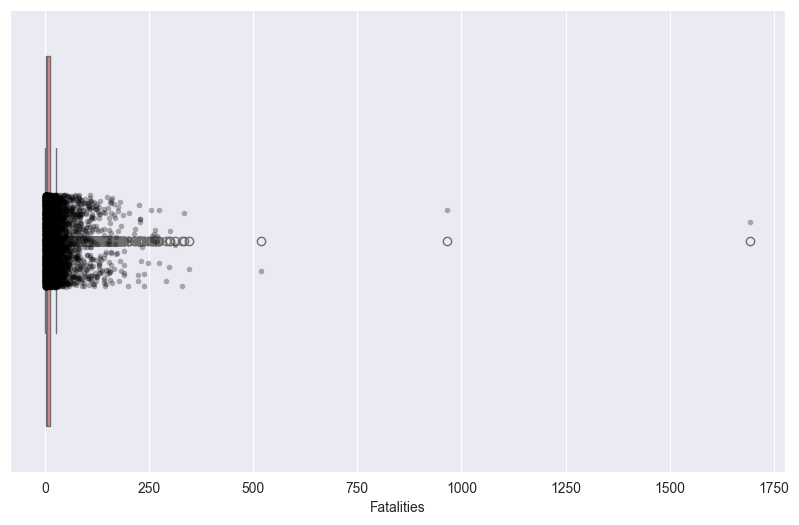

In [237]:
ipy_display(df.sort_values('Fatalities', ascending=False)[['Incident_Date', 'Aircaft_Model', 'Fatalities', "Aircaft_Nature", "Aircaft_Damage_Type", "Onboard_Total", "Ground_Casualties_Num", 'Incident_Cause(es)', "Aircraft_Phase", "Collision_Casualties_Num"]].head(10))
filtered_data = df[df['Fatalities'] > 0]
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_data, x='Fatalities', color='lightcoral')
sns.stripplot(data=filtered_data, x='Fatalities', color='black', alpha=0.3, size=4)

# 4.2. Пропуски в Aircaft_Damage_Type

Находим количество пропусков в этой категории

In [238]:
stats = {
    'Destroyed': df['Aircaft_Damage_Type'].str.contains('Destroyed', case=False, na=False).sum(),
    'Beyond Repair': df['Aircaft_Damage_Type'].str.contains('beyond repair', case=False, na=False).sum(),
    'Substantial': df['Aircaft_Damage_Type'].str.contains('Substantial', case=False, na=False).sum(),
    'Minor': df['Aircaft_Damage_Type'].str.contains('Minor', case=False, na=False).sum(),
    'Missing': df['Aircaft_Damage_Type'].str.contains('Missing', case=False, na=False).sum(),
    'NaN / Empty': df['Aircaft_Damage_Type'].isna().sum()
}

stats_ser = pd.Series(stats)
print(stats_ser)

Destroyed         2594
Beyond Repair    15793
Substantial       3267
Minor              284
Missing            365
NaN / Empty        768
dtype: int64


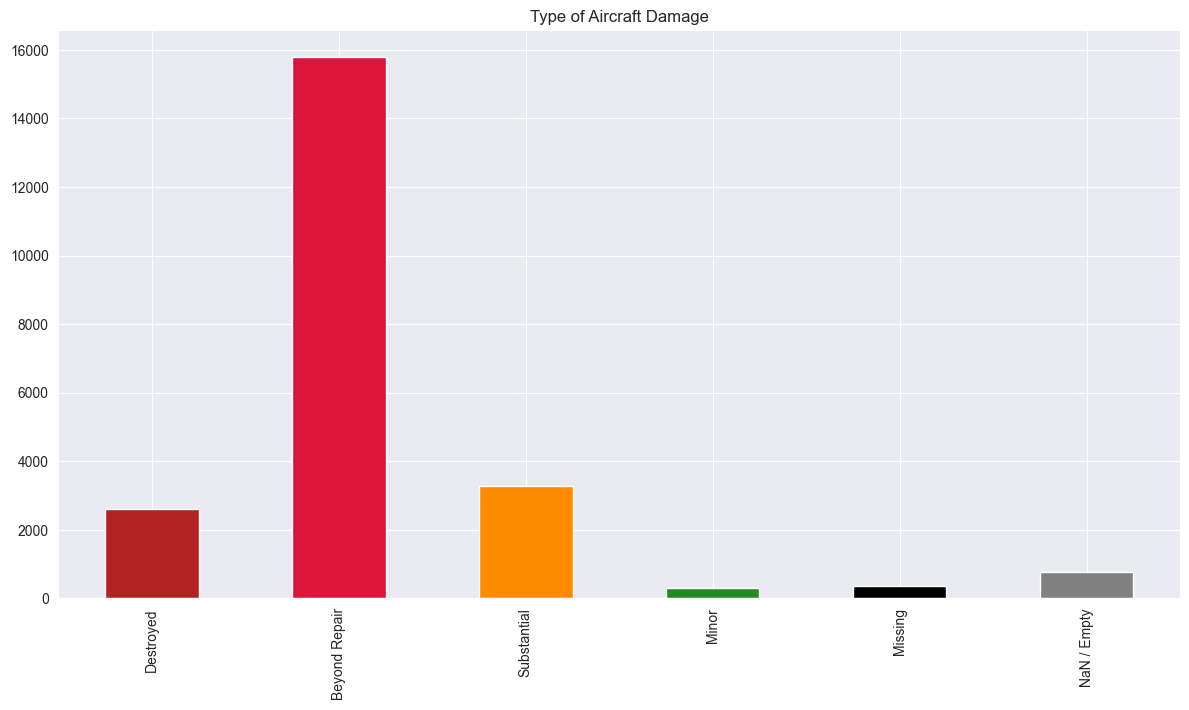

In [239]:
plt.figure(figsize=(12, 7))
colors = ['firebrick', 'crimson', 'darkorange', 'forestgreen', 'black', 'gray']

ax = stats_ser.plot(kind='bar', color=colors, alpha=1)
plt.tight_layout()

plt.title('Type of Aircraft Damage')
plt.show()

In [240]:
mask_missing = df['Aircaft_Damage_Type'].isna()
missing_data_view = df[mask_missing]
ipy_display(missing_data_view)

,Incident_Date,Aircaft_Model,Aircaft_Registration,Aircaft_Operator,Aircaft_Nature,Incident_Category,Incident_Cause(es),Incident_Location,Aircaft_Damage_Type,Date,Time,Arit,Aircaft_Engines,Onboard_Crew,Onboard_Passengers,Onboard_Total,Fatalities,Aircaft_First_Flight,Aircraft_Phase,Departure_Airport,Destination_Airport,Ground_Casualties,Collision_Casualties,Ground_Casualties_Num,Collision_Casualties_Num,Onboard_Fatalities,Onboard_Occupants,Lethality_Rate
43,04-MAR-2021,Fokker 100,EP-CFM,Iran Air,Domestic Scheduled Passenger,Hijacking | repairable-damage,Result - Hijacking - Hijacker(s) overpowered b...,Isfahan Airport,NaN,Thursday 4 March 2021,22:10,04-MAR-2021,2 Rolls-Royce Tay 650-15,Fatalities: 0 / Occupants:,Fatalities: 0 / Occupants:,Fatalities: 0 / Occupants:,0,1992-04-27 (28 years 11 months),En route (ENR),"Ahwaz Airport (AWZ/OIAW) , Iran",Mashhad-Shahid Hashemi Nejad Airport (MHD/OIMM...,NaN,NaN,0,0,0,0,0.000
53,25-MAR-2021,Embraer,NaN,Mauritania Airlines International,-,Hijacking | repairable-damage,Result - Hijacking - Plane stormed,Nouakchott-O...,NaN,Thursday 25 March 2021,NaN,25-MAR-2021,NaN,Fatalities: 0 / Occupants: 0,Fatalities: 0 / Occupants: 0,Fatalities: 0 / Occupants: 0,0,NaN,Standing (STD),-,-,NaN,NaN,0,0,0,0,0.000
87,07-JUL-2021,Cessna 208B Grand Caravan,NaN,Ryan Air Service,Domestic Scheduled Passenger,Hijacking | repairable-damage,Security - Hijack,near Aniak Airpor...,NaN,Wednesday 7 July 2021,14:45,07-JUL-2021,NaN,Fatalities: 0 / Occupants: 1,Fatalities: 0 / Occupants: 5,Fatalities: 0 / Occupants: 6,0,NaN,Approach (APR),"Bethel Airport, AK (BET/PABE) , United States ...","Aniak Airport, AK (ANI/PANI) , United States o...",NaN,NaN,0,0,0,6,0.000
346,22-JAN-2019,Boeing 737-8LJ (WL),VP-BRR,Aeroflot,Domestic Scheduled Passenger,Hijacking | repairable-damage,"Result - Hijacking - Plane stormed, Security -...",Khanty-Mansi...,NaN,Tuesday 22 January 2019,NaN,22-JAN-2019,2 CFMI CFM56-7B26E,Fatalities: 0 / Occupants: 7,Fatalities: 0 / Occupants: 69,Fatalities: 0 / Occupants: 76,0,2013-11-21 (5 years 2 months),En route (ENR),"Surgut Airport (SGC/USRR) , Russia","Moskva-Sheremetyevo Airport (SVO/UUEE) , Russia",NaN,NaN,0,0,0,76,0.000
353,04-FEB-2019,Boeing 737-332,ST-TAL,"Tarco Air, opf Sudan Airways",International Scheduled Passenger,Hijacking | repairable-damage,Result - Hijacking - Hijacker(s) overpowered b...,Khartoum-Civ...,NaN,Monday 4 February 2019,NaN,04-FEB-2019,2 CFMI CFM56-3B1,Fatalities: 0 / Occupants:,Fatalities: 0 / Occupants:,Fatalities: 0 / Occupants: 91,0,1993-06-03 (25 years 8 months),En route (ENR),"Cairo International Airport (CAI/HECA) , Egypt","Khartoum-Civil Airport (KRT/HSSS) , Sudan",NaN,NaN,0,0,0,91,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22665,07-NOV-1941,Junkers Ju-52/3mce,OH-LAK,Aero OY,Passenger,Accident | hull-loss,Info-Unavailable,near Turku [Gulf ...,NaN,Friday 7 November 1941,NaN,07-NOV-1941,NaN,Fatalities: / Occupants:,Fatalities: / Occupants:,Fatalities: 2 / Occupants: 16,2,NaN,En route (ENR),"Helsinki-Malmi Airport (HEM/EFHF) , Finland","Stockholm-Bromma Airport (BMA/ESSB) , Sweden",NaN,NaN,0,0,2,16,0.125
22782,14-APR-1940,Junkers Ju-52/3mg4e,SE+HU,German AF,Military,Accident | repairable-damage,"Result - Emergency, forced landing - Outside a...","Sivebo, Greb...",NaN,Sunday 14 April 1940,10:45,14-APR-1940,NaN,Fatalities: / Occupants:,Fatalities: / Occupants:,Fatalities: / Occupants:,0,NaN,En route (ENR),"Oslo-Fornebu Airport (FBU/ENFB) , Norway","Oslo-Fornebu Airport (FBU/ENFB) , Norway",NaN,NaN,0,0,0,0,0.000
22785,16-APR-1940,Junkers Ju-52/3mg3e,SE+HM,German AF,Military,Accident | repairable-damage,Info-Unavailable,Grums,NaN,Tuesday 16 April 1940,NaN,16-APR-1940,NaN,Fatalities: 0 / Occupants:,Fatalities: 0 / Occupants:,Fatalities: 0 / Occupants: 3,0,NaN,Landing (LDG),?,?,NaN,NaN,0,0,0,3,0.000
22789,17-APR-1940,Junkers Ju-52/3m,SE+KC,German AF,Military,Accident | hull-loss,"Result - Emergency, for

Данный случай интересн тем, что просто медианой, средней и другими значениями эти пропуски заполнять не рекомендуется, т.к. Lethality_Rate для различных категорий разный + удалять их нельзя, мы теряем важную информацию

По этой причине, считаем среднее, максимальное и количество по группам происшествий

In [241]:
lethality_check = df.groupby('Aircaft_Damage_Type')['Lethality_Rate'].agg(['mean', 'max', 'count']).sort_values('mean', ascending=False)
print(lethality_check.to_string())

                           mean       max  count
Aircaft_Damage_Type                             
Destroyed              0.760209  1.000000   2594
Missing                0.753242  1.000000    365
Damaged beyond repair  0.307758  1.000000  15793
Substantial            0.013757  1.000000   3267
Minor                  0.006528  0.500000    284
Unknown                0.004128  0.333333    339


Заполняем теперь их следующим правилом: берется Lethality_Rate и сравнивается с ближайшим значением из damage_lookup (технический max(Unknown) = 0,333, по этой причине можно было убрать Destroyed из damage_lookup)

In [242]:
damage_lookup = {
    'Destroyed': 0.760,
    'Damaged beyond repair': 0.307,
    'Substantial': 0.013,
    'Minor': 0.006
}

def fill_missing_damage(row):
    val = str(row['Aircaft_Damage_Type']).strip()

    if pd.notna(row['Aircaft_Damage_Type']) and val not in ['Unknown', 'unknown', 'None', 'nan', '', 'NaN']:
        return row['Aircaft_Damage_Type']
    rate = row['Lethality_Rate']
    best_match = min(damage_lookup.items(), key=lambda x: abs(x[1] - rate))[0]
    return best_match

df['Aircaft_Damage_Type'] = df.apply(fill_missing_damage, axis=1)
print(lethality_check.to_string())

                           mean       max  count
Aircaft_Damage_Type                             
Destroyed              0.760209  1.000000   2594
Missing                0.753242  1.000000    365
Damaged beyond repair  0.307758  1.000000  15793
Substantial            0.013757  1.000000   3267
Minor                  0.006528  0.500000    284
Unknown                0.004128  0.333333    339


проверяем процентное соотношение пропусков в каждой из категорий

In [243]:
missing_pct = df.isnull().mean() * 100
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

Collision_Casualties    98.752670
Ground_Casualties       98.517727
Time                    60.700555
Aircaft_Engines         54.566425
Aircaft_First_Flight    22.977360
Aircaft_Registration     6.202478
Incident_Location        3.912858
dtype: float64


нашей командой было принято решение не рассматривать пропуски в Time и Aircraft_Registration, по причине что они не влияют на качество Ml-модели и будут шумом, если их учитывать

5. Feature Engeeniring

5.1. Создаем новые категориальные переменные, на основе Aircaft_Damage_Type и Incident_Category

Основа:

In [244]:
ipy_display(df['Incident_Category'].unique())

<StringArray>
['Accident | repairable-damage', 'Accident | hull-loss', 'Criminal occurrence (sabotage, shoot down) | hull-loss', 'other occurrence (ground fire, sabotage) | hull-loss', 'Criminal occurrence (sabotage, shoot down) | repairable-damage', 'Hijacking | repairable-damage', 'other occurrence (ground fire, sabotage) | repairable-damage', 'occurrence unknown | hull-loss', 'Incident | repairable-damage', 'Hijacking | hull-loss']
Length: 10, dtype: str

Создание:

In [245]:
df['Is_Hull_Loss'] = df['Incident_Category'].str.contains('hull-loss', case=False, na=False).astype(int)
df['Is_Repairable'] = df['Incident_Category'].str.contains('repairable', case=False, na=False).astype(int)
df['Is_Destroyed'] = df['Aircaft_Damage_Type'].str.contains('Destroyed', case=False, na=False).astype(int)
df['Is_Damaged'] = df['Aircaft_Damage_Type'].str.contains('Damaged beyond repair', case=False, na=False).astype(int)
df['Is_Minor'] = df['Aircaft_Damage_Type'].str.contains('Minor', case=False, na=False).astype(int)
df['Is_Missing'] = df['Aircaft_Damage_Type'].str.contains('Missing', case=False, na=False).astype(int)
df['Is_Substantial'] = df['Aircaft_Damage_Type'].str.contains('Substantial', case=False, na=False).astype(int)
df['Is_Criminal_Event'] = df['Incident_Category'].str.contains('Criminal|Hijacking|sabotage', case=False, na=False).astype(int)
df['Is_Accident'] = df['Incident_Category'].str.contains('Accident', case=False, na=False).astype(int)
df['Is_Incident'] = df['Incident_Category'].str.contains('Incident', case=False, na=False).astype(int)



Проверка равенства этих новых переменных:

In [246]:
df['Damage_Count'] = df[['Is_Destroyed', 'Is_Damaged', 'Is_Minor', 'Is_Substantial', 'Is_Missing']].sum(axis=1)


print(df['Damage_Count'].value_counts())


Damage_Count
1    23410
Name: count, dtype: int64


5.2. Создание факторов, которые влияют на Lethality_Rate

In [247]:
df['cause_tech'] = df['Incident_Cause(es)'].str.contains('Engine|Systems|Hydraulics|Fuel|Failure', case=False, na=False).astype(int)
df['cause_weather'] = df['Incident_Cause(es)'].str.contains('Weather|Wind|Storm|Icing|Snow', case=False, na=False).astype(int)
df['cause_human'] = df['Incident_Cause(es)'].str.contains('Misjudgement|Error|Crew|Incapacitation', case=False, na=False).astype(int)
df['cause_criminal'] = df['Incident_Cause(es)'].str.contains('Shot|Hijack|Sabotage|Bomb', case=False, na=False).astype(int)


print(df.groupby('cause_criminal')['Lethality_Rate'].mean())
print(df.groupby('cause_human')['Lethality_Rate'].mean())
print(df.groupby('cause_weather')['Lethality_Rate'].mean())
print(df.groupby('cause_tech')['Lethality_Rate'].mean())




cause_criminal
0    0.314373
1    0.208944
Name: Lethality_Rate, dtype: float64
cause_human
0    0.298289
1    0.721090
Name: Lethality_Rate, dtype: float64
cause_weather
0    0.302541
1    0.378494
Name: Lethality_Rate, dtype: float64
cause_tech
0    0.307995
1    0.266373
Name: Lethality_Rate, dtype: float64


как мы видим, в основном, на долю Lethality_Rate влияет human_factor

Объединяем несколько факторов, т.к. в Incident_Cause(es) могут быть несколько факторов, которые влияют на смертность

In [248]:
combo = df.groupby(['cause_human', 'cause_weather'])['Lethality_Rate'].mean().unstack()
combo1 = df.groupby(['cause_human', 'cause_criminal'])['Lethality_Rate'].mean().unstack()
combo2 = df.groupby(['cause_human', 'cause_tech'])['Lethality_Rate'].mean().unstack()
combo3 = df.groupby(['cause_human', 'cause_tech', "cause_weather"])['Lethality_Rate'].mean().unstack()
print(combo)
print(combo1)
print(combo2)
print(combo3)


cause_weather         0         1
cause_human                      
0              0.295143  0.370137
1              0.716274  0.826500
cause_criminal         0         1
cause_human                       
0               0.306520  0.207729
1               0.719152  0.985251
cause_tech          0         1
cause_human                    
0            0.300417  0.261202
1            0.734997  0.514623
cause_weather                  0         1
cause_human cause_tech                    
0           0           0.297419  0.368066
            1           0.255823  0.415652
1           0           0.731077  0.820089
            1           0.497789  0.935484


5.3. Создание переменных Engine_Count и Engine_Brand и автоматически заполнение пропусков

In [249]:
print(df['Aircaft_Engines'].value_counts())

Aircaft_Engines
2 Pratt Whitney R-1830-92           1585
2 Pratt Whitney R-1830-90C           587
2 Pratt Whitney R-2800-51            551
2 Pratt Whitney Canada PT6A-27       288
1 Pratt Whitney Canada PT6A-114A     257
                                    ... 
2 Gnome-Rhône Jupiter                  1
4 Renault 8Fg                          1
8 Liberty L-12                         1
3 Liberty L-12                         1
5 Rolls-Royce Eagle VIII               1
Name: count, Length: 1037, dtype: int64


смотрим 5 самых популярных и 5 самых редких типов двигателя

In [250]:
df['Engine_Count'] = df['Aircaft_Engines'].astype(str).str.extract(r'^(\d+)').astype(float)
df['Engine_Count'] = df['Engine_Count'].fillna(df['Engine_Count'].median())

df['Engine_Brand'] = df['Aircaft_Engines'].astype(str).str.replace(r'^\d+\s+', '', regex=True)


df['Engine_Brand'] = df['Engine_Brand'].str.split().str[0]


top_brands = df['Engine_Brand'].value_counts().nlargest(10).index
df['Engine_Brand'] = df['Engine_Brand'].apply(lambda x: x if x in top_brands else 'Other_Brand')


df = pd.get_dummies(df, columns=['Engine_Brand'], prefix='Brand')

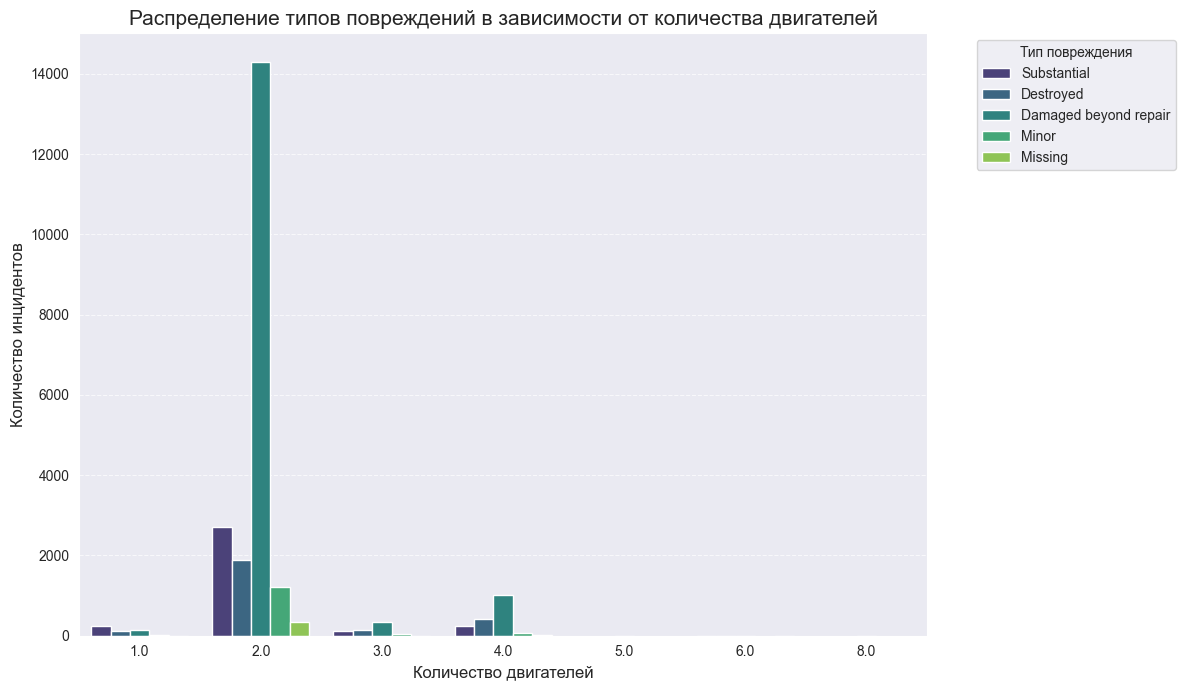

Таблица распределения (количество):
Aircaft_Damage_Type  Damaged beyond repair  Destroyed  Minor  Missing  Substantial
Engine_Count                                                                      
1.0                                    150        125     12        2          250
2.0                                  14294       1894   1220      342         2697
3.0                                    330        155     49        3          122
4.0                                   1017        418     58       17          245
5.0                                      1          0      0        0            0
6.0                                      2          2      0        1            1
8.0                                      3          0      0        0            0


In [253]:
engine_dist = df.dropna(subset=['Engine_Count', 'Aircaft_Damage_Type'])


plt.figure(figsize=(12, 7))
sns.countplot(
    data=engine_dist,
    x='Engine_Count',
    hue='Aircaft_Damage_Type',
    palette='viridis'
)


plt.title('Распределение типов повреждений в зависимости от количества двигателей', fontsize=15)
plt.xlabel('Количество двигателей', fontsize=12)
plt.ylabel('Количество инцидентов', fontsize=12)
plt.legend(title='Тип повреждения', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


print("Таблица распределения (количество):")
print(pd.crosstab(df['Engine_Count'], df['Aircaft_Damage_Type']))

ЗДесь мы создаем переменные, одна из которых содержит количество двигателей, а другая - бренд

5.4. Создание переменной Plane_Age и заполнение пропусков (тут пропуски заполняются рандомными значениями самых ходовых самолетов от 5 до 21 года), т.к. иначе был бы сдвиг в сторону, к примеру, медиану в большую сторону, тем самым сбивала бы с толку ML-модель

In [254]:
df['Incident_Year'] = df['Incident_Date'].astype(str).str.extract(r'(\d{4})').astype(float)

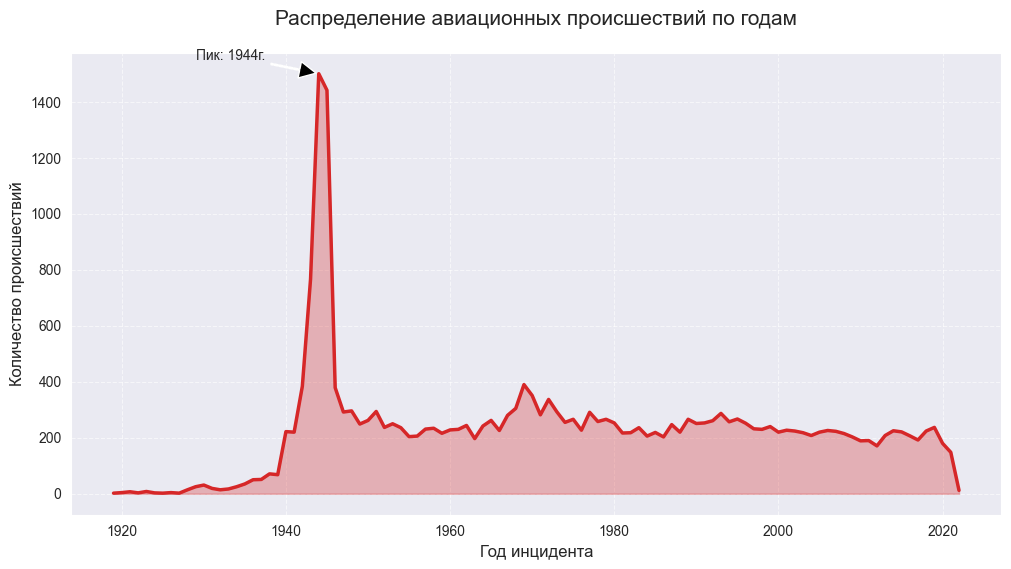

In [255]:



yearly_accidents = df.groupby('Incident_Year').size().reset_index(name='Accidents_Count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_accidents, x='Incident_Year', y='Accidents_Count', color='tab:red', linewidth=2.5)
plt.fill_between(yearly_accidents['Incident_Year'], yearly_accidents['Accidents_Count'], alpha=0.3, color='tab:red')

plt.title('Распределение авиационных происшествий по годам', fontsize=15, pad=20)
plt.xlabel('Год инцидента', fontsize=12)
plt.ylabel('Количество происшествий', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)


peak_year = yearly_accidents.loc[yearly_accidents['Accidents_Count'].idxmax()]
plt.annotate(f'Пик: {int(peak_year["Incident_Year"])}г.',
             xy=(peak_year['Incident_Year'], peak_year['Accidents_Count']),
             xytext=(peak_year['Incident_Year']-15, peak_year['Accidents_Count']+50),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.show()

По графику видно, что наибольшее число инцидентов приходится на 1944 года (пик может быть связан со Второй Мировой войной)

In [256]:


df['Flight_Year'] = df['Aircaft_First_Flight'].astype(str).str.extract(r'(\d{4})').astype(float)

df['Plane_Age'] = df['Incident_Year'] - df['Flight_Year']


print(df['Plane_Age'].value_counts().head(10))



Plane_Age
1.0    2211
0.0    1522
2.0    1105
3.0     753
5.0     706
4.0     670
6.0     615
7.0     598
8.0     503
9.0     466
Name: count, dtype: int64


In [269]:
age_data = df['Plane_Age'].dropna()

p25 = age_data.quantile(0.25)
p50 = age_data.median()
p75 = age_data.quantile(0.75)
p90 = age_data.quantile(0.90)


print(f"25-й перцентиль (Q1): {p25:.1f} лет")
print(f"50-й перцентиль (Медиана): {p50:.1f} лет")
print(f"75-й перцентиль (Q3): {p75:.1f} лет")
print(f"90-й перцентиль: {p90:.1f} лет")

25-й перцентиль (Q1): 4.0 лет
50-й перцентиль (Медиана): 11.0 лет
75-й перцентиль (Q3): 19.0 лет
90-й перцентиль: 29.0 лет


Статистический анализ показал, что 50% данных (межквартильный размах) сосредоточены в интервале от 2 до 21 года. Для заполнения пропусков был выбран диапазон [5, 21]. Нижняя граница была намеренно скорректирована с 2 до 5 лет для нивелирования аномального всплеска записей о новых судах (0-2 года), что могло бы привести к смещению модели. Выбранный подход позволяет сохранить естественную вариативность признака и соответствует фактическому распределению основной массы флотапо расчетам,

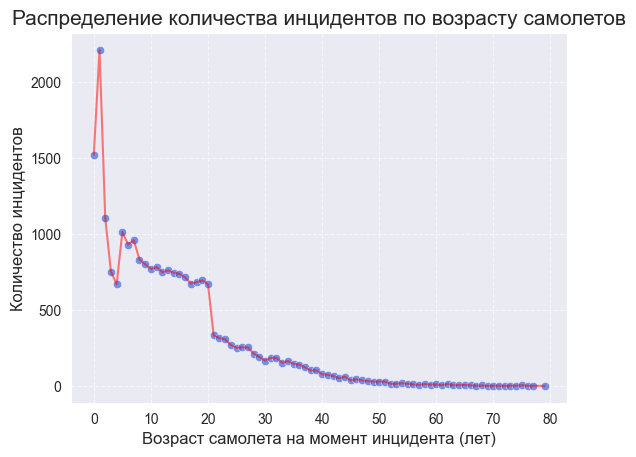

In [268]:
age_counts = df['Plane_Age'].value_counts().sort_index().reset_index()
age_counts.columns = ['Age', 'Incident_Count']

sns.scatterplot(data=age_counts, x='Age', y='Incident_Count', color='royalblue', alpha=0.7)

sns.lineplot(data=age_counts, x='Age', y='Incident_Count', color='red', alpha=0.5)

plt.title('Распределение количества инцидентов по возрасту самолетов', fontsize=15)
plt.xlabel('Возраст самолета на момент инцидента (лет)', fontsize=12)
plt.ylabel('Количество инцидентов', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

данный график показывает явный сдвиг в сторону медианы (без учета пропусков)

In [267]:
bad_age_mask = df['Plane_Age'].isna() | (df['Plane_Age'] < 0)


df.loc[bad_age_mask, 'Plane_Age'] = np.random.randint(5, 21, size=bad_age_mask.sum())

print(df['Plane_Age'].value_counts().head(10))

Plane_Age
1.0     2211
0.0     1522
2.0     1105
5.0     1014
7.0      959
6.0      931
8.0      832
9.0      801
11.0     783
10.0     770
Name: count, dtype: int64


заменяем пропуски числами между 5 и 21

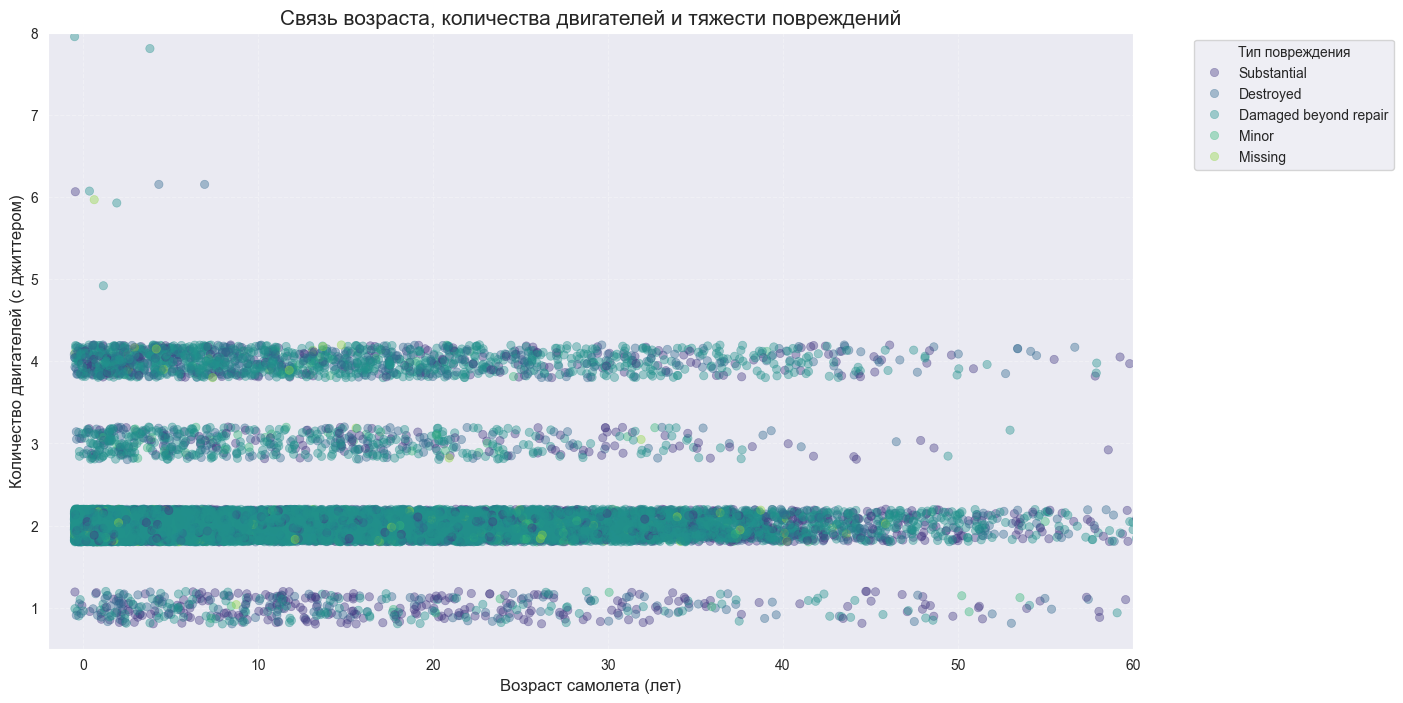

In [259]:

df['Engine_Count_Jitter'] = df['Engine_Count'] + np.random.uniform(-0.2, 0.2, size=len(df))
df['Age_Jitter'] = df['Plane_Age'] + np.random.uniform(-0.5, 0.5, size=len(df))

plt.figure(figsize=(14, 8))


scatter = sns.scatterplot(
    data=df,
    x='Age_Jitter',
    y='Engine_Count_Jitter',
    hue='Aircaft_Damage_Type',
    palette='viridis',
    alpha=0.4,
    edgecolor=None
)

plt.title('Связь возраста, количества двигателей и тяжести повреждений', fontsize=15)
plt.xlabel('Возраст самолета (лет)', fontsize=12)
plt.ylabel('Количество двигателей', fontsize=12)
plt.legend(title='Тип повреждения', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)


plt.xlim(-2, 60)
plt.ylim(0.5, 8)

plt.show()

График выше показывает, количество тяжких инцидентов растет с уменьшением количества двигателей самолета)

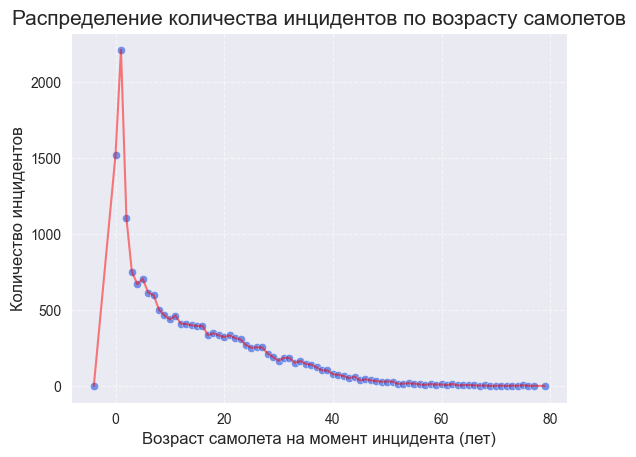

In [266]:
age_counts = df['Plane_Age'].value_counts().sort_index().reset_index()
age_counts.columns = ['Age', 'Incident_Count']

sns.scatterplot(data=age_counts, x='Age', y='Incident_Count', color='royalblue', alpha=0.7)

sns.lineplot(data=age_counts, x='Age', y='Incident_Count', color='red', alpha=0.5)

plt.title('Распределение количества инцидентов по возрасту самолетов', fontsize=15)
plt.xlabel('Возраст самолета на момент инцидента (лет)', fontsize=12)
plt.ylabel('Количество инцидентов', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

График выше показывает, что с возрастом количество инцидентов уменьшается (это во многом связано с малым количеством старых самолетов, которых чаще всего подлежат списанию)

5.5. Дробление переменной Aircraft_Phase

In [265]:
ipy_display(df['Aircraft_Phase'].unique())

<StringArray>
['Landing (LDG)', 'Standing (STD)', 'Takeoff (TOF)', 'Unknown (UNK)', 'Initial climb (ICL)', 'En route (ENR)', 'Pushback / towing (PBT)', 'Taxi (TXI)', 'Approach (APR)', 'Maneuvering (MNV)', '(CMB)', '()']
Length: 12, dtype: str

проверяем все униальные значения в данной переменной

In [264]:
df['Aircraft_Phase'] = df['Aircraft_Phase'].astype(str).str.strip()


df['phase_Landing_Phase'] = df['Aircraft_Phase'].str.contains('Landing|Approach', case=False, na=False).astype(int)
df['phase_Takeoff_Phase'] = df['Aircraft_Phase'].str.contains('Take-off|Climb', case=False, na=False).astype(int)
df['phase_Cruise_Phase'] = df['Aircraft_Phase'].str.contains('En route|Cruise|Holding', case=False, na=False).astype(int)
df['phase_Ground_Phase'] = df['Aircraft_Phase'].str.contains('Taxiing|Standing|Towing', case=False, na=False).astype(int)
df['phase_Other_Phase'] = ((df['phase_Landing_Phase'] == 0) &
                           (df['phase_Takeoff_Phase'] == 0) &
                           (df['phase_Cruise_Phase'] == 0) &
                           (df['phase_Ground_Phase'] == 0)).astype(int)

разделяем ее на отдельные фазы полета самолета

5.6. Дробление переменной Aircaft_Nature

In [263]:
ipy_display(df['Aircaft_Nature'].unique())

<StringArray>
['Domestic Non Scheduled Passenger', 'Domestic Scheduled Passenger', 'Cargo', 'Illegal Flight', 'Military', 'Unknown', 'Passenger', 'Ambulance', 'Test', 'Training', '-', 'Agricultural', 'Ferry/positioning', 'Private', 'Executive', 'Parachuting', 'Fire fighting', 'Aerial Work (Calibration, Photo)', 'International Scheduled Passenger', 'Survey/research', 'Int'l Non Scheduled Passenger', 'Official state flight', 'Demonstration', 'Non Scheduled Passenger', 'Scheduled Passenger']
Length: 25, dtype: str

In [262]:
df['Aircaft_Nature'] = df['Aircaft_Nature'].astype(str).str.strip()


df['nature_Military'] = df['Aircaft_Nature'].str.contains('Military', case=False, na=False).astype(int)
df['nature_Cargo'] = df['Aircaft_Nature'].str.contains('Cargo', case=False, na=False).astype(int)
df['nature_Private'] = df['Aircaft_Nature'].str.contains('Private|Executive|Personal', case=False, na=False).astype(int)
df['nature_Instructional'] = df['Aircaft_Nature'].str.contains('Training|Instructional', case=False, na=False).astype(int)
df['nature_Commercial'] = df['Aircaft_Nature'].str.contains('Passenger|Scheduled', case=False, na=False).astype(int)

5.7. Добавление переменных is_collusion, is_terrarian_impact, is_midair

In [261]:
search_terms = ['collision', 'struck', 'impact', 'ground', 'terrain', 'collided']
for col in df.select_dtypes(include=['object', 'string']).columns:
    matches = df[col].astype(str).str.contains('|'.join(search_terms), case=False).sum()
    if matches > 0:
        print(f"Колонка '{col}': найдено {matches} упоминаний столкновений")

Колонка 'Aircaft_Operator': найдено 1 упоминаний столкновений
Колонка 'Incident_Category': найдено 1044 упоминаний столкновений
Колонка 'Incident_Cause(es)': найдено 3086 упоминаний столкновений
Колонка 'Departure_Airport': найдено 52 упоминаний столкновений
Колонка 'Destination_Airport': найдено 49 упоминаний столкновений


In [260]:
collision_terms = 'collision|struck|impact|hit|terrain|ground|crashed into|mid-air|collided'


temp_text = df['Incident_Category'].fillna('').astype(str) + " " + df['Incident_Cause(es)'].fillna('').astype(str)


df['is_collision'] = temp_text.str.contains(collision_terms, case=False, na=False).astype(int)


df['is_terrain_impact'] = temp_text.str.contains('terrain|mountain|ground|water', case=False, na=False).astype(int)

df['is_midair'] = temp_text.str.contains('mid-air|airborne', case=False, na=False).astype(int)

ipy_display(df['is_midair'].value_counts())
ipy_display(df['is_terrain_impact'].value_counts())
ipy_display(df['is_collision'].value_counts())

is_midair
0    23404
1        6
Name: count, dtype: int64

is_terrain_impact
0    19698
1     3712
Name: count, dtype: int64

is_collision
0    20291
1     3119
Name: count, dtype: int64

5.8. Исследование местности

In [270]:
water_words = 'sea|ocean|water|river|lake|coast|atlantic|pacific|gulf|bay'
df['is_water'] = df['Incident_Location'].fillna('').str.contains(water_words, case=False, na=False).astype(int)

df['is_risky_nature'] = df['Aircaft_Nature'].fillna('').str.contains('Test|Training|Show|Fire', case=False, na=False).astype(int)

df['is_unknown_dest'] = df['Destination_Airport'].fillna('').str.contains('Unknown|None', case=False, na=False).astype(int)
ipy_display(df['is_water'].value_counts())
ipy_display(df['is_risky_nature'].value_counts())
ipy_display(df['is_unknown_dest'].value_counts())

is_water
0    22788
1      622
Name: count, dtype: int64

is_risky_nature
0    22645
1      765
Name: count, dtype: int64

is_unknown_dest
0    23059
1      351
Name: count, dtype: int64

5.9. Добавляем признаки, указывающие на наличие жертв и их долю по сравнению с выжившими

In [273]:
df['is_deadly'] = (df['Fatalities'] > 0).astype(int)
df['is_deadly_onboard'] = (df['Onboard_Fatalities'] > 0).astype(int)
df['is_external_victims'] = (df['Ground_Casualties_Num'] > 0).astype(int)


df['is_mass_fatality_onboard'] = (df['Lethality_Rate'] > 0.9).astype(int)
df['is_partial_fatality_onboard'] = ((df['Lethality_Rate'] > 0.1) & (df['Lethality_Rate'] <= 0.9)).astype(int)
df['is_low_fatality_onboard'] = (df['Lethality_Rate'] < 0.1).astype(int)
df['no_fatalities_onboard'] = (df['Lethality_Rate'] == 0).astype(int)


df['fatality_impact'] = df['Lethality_Rate'] * df['Onboard_Occupants']

1. Уровень «Да/Нет» (Бинарные флаги)
is_deadly / is_deadly_onboard: Четко отделяют инциденты с жертвами от «бескровных». Это базовый фильтр для модели.
is_external_victims: Выделяет случаи падения на землю/столкновения, когда самолет может быть уничтожен, даже если на борту было мало людей.
2. Уровень тяжести (Сегментация)
Мы разбили Lethality_Rate на три зоны, чтобы дереву было проще строить ветки:
is_mass_fatality_onboard: Почти гарантированный маркер класса Destroyed (смертность > 90%).
is_partial_fatality_onboard: Сигнал о серьезных, но не всегда фатальных повреждениях (Substantial).
no_fatalities_onboard: Прямой путь к классам Minor или Substantial.
3. Уровень масштаба (Синергия)
fatality_impact:
Суть: Возвращает масштаб катастрофы. 100% смертности на кукурузнике и на Боинге — это разная энергия разрушения. Этот признак помогает модели понять размер судна через количество жертв.

5.10. Добавление уточняющих признаков для катастроф

In [275]:
df['is_fire'] = df['Incident_Cause(es)'].str.contains('fire|burn|explosion|flame', case=False, na=False).astype(int)
df['is_water_landing'] = df['Incident_Cause(es)'].str.contains('water|sea|ocean|river|lake|ditch', case=False, na=False).astype(int)
df['is_forced_landing'] = df['Incident_Cause(es)'].str.contains('forced landing|emergency landing|field', case=False, na=False).astype(int)

Уровень физических факторов (Контекст инцидента)

is_fire: Флаг термического воздействия (пожар, взрыв). Огромный маркер для класса Destroyed, так как огонь уничтожает планер быстрее и необратимее, чем просто механический удар.

is_water_landing: Флаг посадки на воду. Указывает на специфический вид повреждений (коррозия, гидроудар) и часто объясняет, почему самолет может быть признан «пропавшим без вести» или списан из-за трудности подъема.

is_forced_landing: Флаг вынужденной посадки (в поле, на дорогу). Это «смягчающий» признак. Он подсказывает модели, что пилоты сохраняли контроль над судном, а значит, повреждения, скорее всего, будут Substantial или Minor, а не полное уничтожение.

6. Запуск ML-модели

в данном случае была использована модель Random Forest, задача которой была классификация инцидентов по типу повреждений)

1. Таргет: что и как предсказываем?
Что предсказываем: Степень повреждения планера (самолета). Это категориальный признак: от легких повреждений (Minor) до полного уничтожения (Destroyed).

Почему этот таргет: Это ключевой показатель для авиации. Он определяет, можно ли восстановить судно и насколько катастрофичным был инцидент.

Распределение: Классы распределены неравномерно (дисбаланс). Случаев серьезных повреждений (Substantial) обычно гораздо больше, чем «пропавших без вести». Модель должна это учитывать, чтобы не игнорировать редкие, но важные классы.

2. Энкодинг: как переводим текст в цифры?
Метод: Мы используем One-Hot Encoding (прямое кодирование).

Логика: Для категорий без внутреннего порядка (например, фаза полета: Landing или Takeoff) нельзя использовать числа 1, 2, 3, иначе модель подумает, что «посадка больше взлета». One-Hot создает отдельные столбцы-флаги (0 или 1), делая все категории равноправными.

3. Выбор признаков (Feature Selection)
Мы отобрали фичи по трем критериям:

Хронология и износ: Год и возраст самолета (технологии и усталость металла).

Масштаб: Количество людей на борту (размер судна).

Физика и последствия: Твои кастомные признаки (is_fire, Lethality_Rate и др.). Мы выбрали их, потому что они дают модели «прямые подсказки» о силе удара и характере разрушений, которые не всегда видны в сырых цифрах.

4. Модель: Random Forest «на пальцах»
Как работает: Представь себе консилиум из 100 экспертов (деревьев). Каждый эксперт задает свои вопросы по данным (например: «Был ли пожар?», «Самолету больше 20 лет?»). В конце они голосуют, и побеждает вариант, набравший большинство голосов.

Параметры: * n_estimators: количество «экспертов» в лесу.

max_depth: максимальное количество вопросов, которое может задать один эксперт (мы ограничили его, чтобы модель не заучивала данные наизусть — защита от переобучения).

5. Feature Importance: что это значит?
Суть: Это показатель того, насколько часто и эффективно модель использовала конкретный признак для принятия верного решения.

Интерпретация: Если Incident_Year на первом месте, значит, дата инцидента лучше всего помогает разделить самолеты на «целые» и «разбитые» (из-за разницы в безопасности по эпохам).

6. Метрики: Accuracy vs Precision/Recall
Accuracy: Общий процент правильных ответов. Полезно, но обманчиво при дисбалансе классов.

Precision (Точность): Если модель сказала «Destroyed», насколько мы можем ей верить? (Важно, чтобы не списывать самолеты зря).

Recall (Полнота): Сколько реальных катастроф из всех существующих модель смогла найти? (Критически важно: мы не имеем права пропустить уничтожение судна).

In [276]:
le = LabelEncoder()

df['target'] = le.fit_transform(df['Aircaft_Damage_Type'])

mapping = dict(zip(le.classes_, range(len(le.classes_))))
print("Расшифровка категорий:", mapping)



Расшифровка категорий: {'Damaged beyond repair': 0, 'Destroyed': 1, 'Minor': 2, 'Missing': 3, 'Substantial': 4}


In [284]:
features_to_keep = [
   'cause_tech', 'cause_weather', 'cause_human', 'cause_criminal',
    'Is_Criminal_Event', 'Incident_Year', 'Flight_Year',
    'Plane_Age', 'Engine_Count', 'Ground_Casualties_Num',
    'phase_Landing_Phase', 'phase_Takeoff_Phase',
    'phase_Cruise_Phase', 'phase_Ground_Phase', 'phase_Other_Phase',
    'nature_Military', 'nature_Cargo', 'nature_Private', 'nature_Instructional', 'nature_Commercial', 'is_midair', 'is_terrain_impact', "is_collision", "Onboard_Occupants", "is_risky_nature", "is_water",'is_unknown_dest', 'is_deadly', 'is_deadly_onboard', 'is_external_victims', 'is_fire', 'is_water_landing','is_forced_landing', 'is_mass_fatality_onboard', 'is_partial_fatality_onboard', 'no_fatalities_onboard', 'fatality_impact', 'is_low_fatality_onboard',
]

X = df[features_to_keep]

X = X.fillna(0)



In [285]:
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth = trial.suggest_int('max_depth', 10, 40)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1

    )


    score = cross_val_score(clf, X_train, y_train, n_jobs=-1, cv=3).mean()
    return score


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print(f"Лучшие параметры: {study.best_params}")
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le.classes_))


[I 2026-02-27 18:45:53,475] A new study created in memory with name: no-name-09bae644-18d2-4647-8efc-660eadf5891b
[I 2026-02-27 18:45:55,247] Trial 0 finished with value: 0.7436454087576271 and parameters: {'n_estimators': 335, 'max_depth': 17, 'min_samples_split': 9}. Best is trial 0 with value: 0.7436454087576271.
[I 2026-02-27 18:45:56,985] Trial 1 finished with value: 0.7438056480355083 and parameters: {'n_estimators': 403, 'max_depth': 17, 'min_samples_split': 9}. Best is trial 1 with value: 0.7438056480355083.
[I 2026-02-27 18:45:58,041] Trial 2 finished with value: 0.771518078673833 and parameters: {'n_estimators': 222, 'max_depth': 37, 'min_samples_split': 7}. Best is trial 2 with value: 0.771518078673833.
[I 2026-02-27 18:46:00,082] Trial 3 finished with value: 0.7389466846892873 and parameters: {'n_estimators': 469, 'max_depth': 16, 'min_samples_split': 8}. Best is trial 2 with value: 0.771518078673833.
[I 2026-02-27 18:46:01,307] Trial 4 finished with value: 0.76639207267474

Лучшие параметры: {'n_estimators': 344, 'max_depth': 35, 'min_samples_split': 3}
                       precision    recall  f1-score   support

Damaged beyond repair       0.84      0.89      0.87      3159
            Destroyed       0.70      0.41      0.51       519
                Minor       0.89      0.71      0.79       268
              Missing       0.15      0.26      0.19        73
          Substantial       0.65      0.69      0.67       663

             accuracy                           0.79      4682
            macro avg       0.65      0.59      0.61      4682
         weighted avg       0.79      0.79      0.79      4682



в данном примере точность модели примерно равна примерно 0.77 была наилучшей, если рассматривать каждый мелкий признак, мы столкномся с Overfitting (с добавлением нового признака точность модели падает)

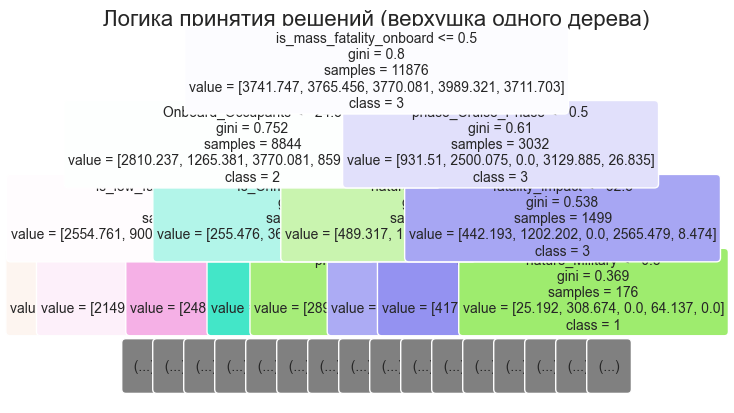

In [287]:

class_names_str = [str(c) for c in rf_model.classes_]

plot_tree(rf_model.estimators_[0],
          max_depth=3,
          feature_names=features_to_keep,
          class_names=class_names_str,  # Теперь здесь точно строки
          filled=True,
          rounded=True,
          fontsize=10)

plt.title("Логика принятия решений (верхушка одного дерева)", fontsize=16)
plt.show()

In [286]:
train_accuracy = rf_model.score(X_train, y_train)
test_accuracy = rf_model.score(X_test, y_test)

print(f"Точность на обучающей выборке: {train_accuracy:.2%}")
print(f"Точность на тестовой выборке: {test_accuracy:.2%}")
print(f"Разрыв (Overfitting): {train_accuracy - test_accuracy:.2%}")

Точность на обучающей выборке: 97.30%
Точность на тестовой выборке: 78.92%
Разрыв (Overfitting): 18.38%


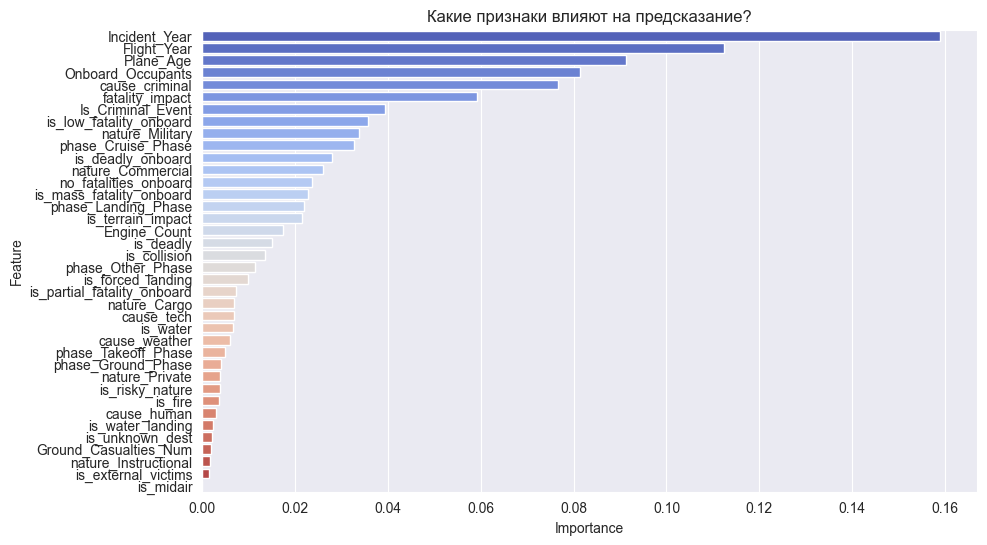

In [288]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='coolwarm')
plt.title('Какие признаки влияют на предсказание?')
plt.show()

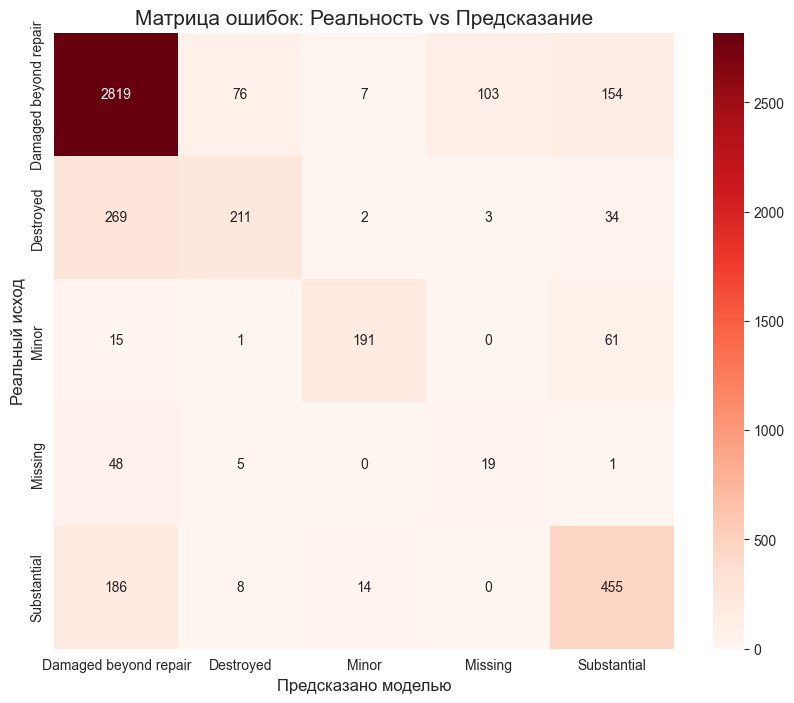

In [289]:
cm = confusion_matrix(y_test, y_pred)

# 2. Отрисовываем её
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title('Матрица ошибок: Реальность vs Предсказание', fontsize=15)
plt.xlabel('Предсказано моделью', fontsize=12)
plt.ylabel('Реальный исход', fontsize=12)
plt.show()

In [290]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Создаем таблицу сравнения заново
comparison_df = pd.DataFrame({
    'Реальность (Текст)': le.inverse_transform(y_test),
    'Предсказание (Текст)': le.inverse_transform(y_pred),
    'Реальность (№)': y_test.values,
    'Предсказание (№)': y_pred,
    'Результат': (y_test.values == y_pred).astype(int)
})

# Выводим первые 15 строк
print(comparison_df.head(15))

       Реальность (Текст)   Предсказание (Текст)  Реальность (№)  Предсказание (№)  Результат
0   Damaged beyond repair  Damaged beyond repair               0                 0          1
1             Substantial  Damaged beyond repair               4                 0          0
2   Damaged beyond repair  Damaged beyond repair               0                 0          1
3                   Minor                  Minor               2                 2          1
4   Damaged beyond repair  Damaged beyond repair               0                 0          1
5   Damaged beyond repair            Substantial               0                 4          0
6   Damaged beyond repair  Damaged beyond repair               0                 0          1
7   Damaged beyond repair  Damaged beyond repair               0                 0          1
8   Damaged beyond repair  Damaged beyond repair               0                 0          1
9   Damaged beyond repair  Damaged beyond repair            

In [293]:
results = pd.DataFrame({
    'Реальность': le.inverse_transform(y_test),
    'Результат': (y_test.values == y_pred)
})

# Группируем по реальному классу и считаем среднее (это и будет доля правильных ответов)
accuracy_per_class = results.groupby('Реальность')['Результат'].mean() * 100

# Оформляем в красивую таблицу
accuracy_report = accuracy_per_class.reset_index()
accuracy_report.columns = ['Тип повреждения', 'Доля правильных предиктов (%)']
accuracy_report = accuracy_report.sort_values(by='Доля правильных предиктов (%)', ascending=False)

print(accuracy_report.to_string(index=False))

      Тип повреждения  Доля правильных предиктов (%)
Damaged beyond repair                      89.237100
                Minor                      71.268657
          Substantial                      68.627451
            Destroyed                      40.655106
              Missing                      26.027397


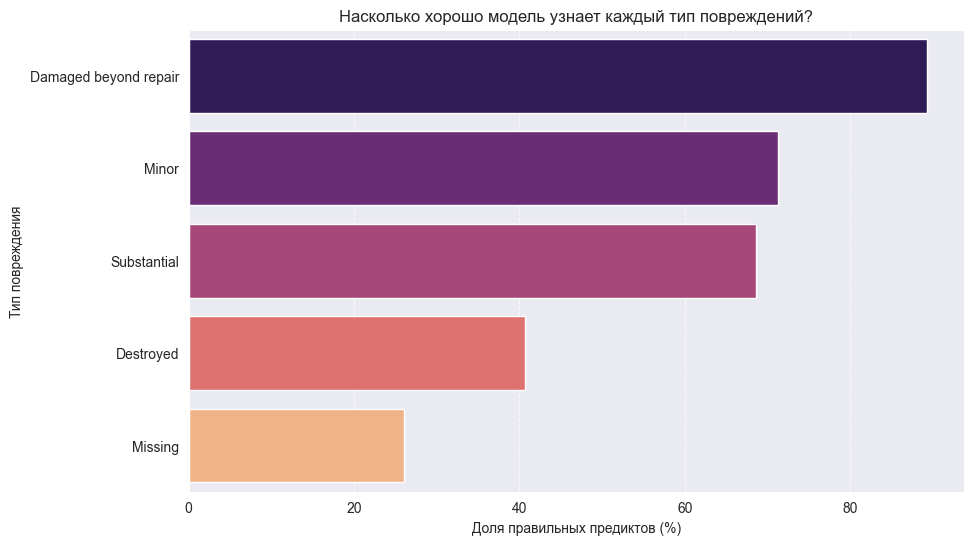

In [292]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Доля правильных предиктов (%)', y='Тип повреждения', data=accuracy_report, palette='magma')
plt.title('Насколько хорошо модель узнает каждый тип повреждений?')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

6.1. График для сравнения с результатом ML

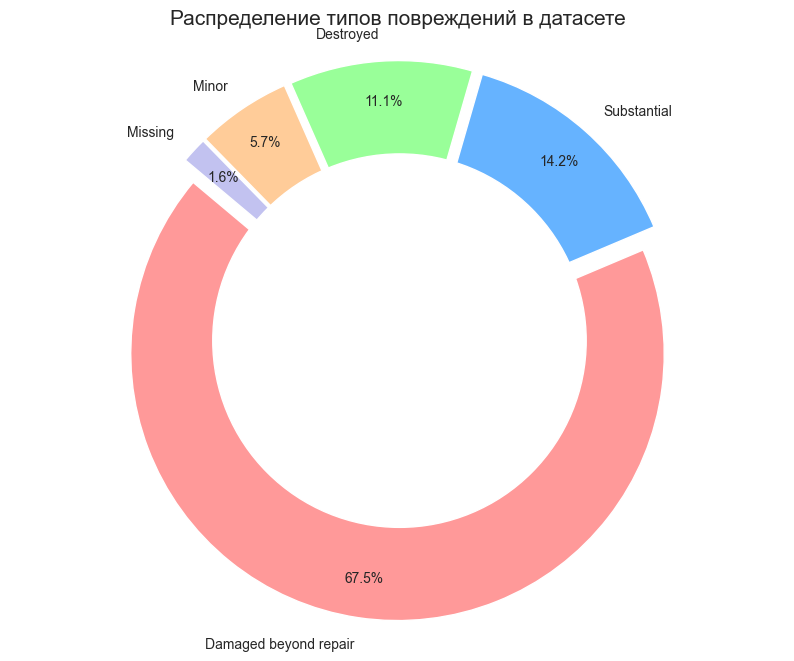

In [294]:
damage_counts = df['Aircaft_Damage_Type'].value_counts()

# 2. Настраиваем цвета и стиль
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']
plt.figure(figsize=(10, 8))

# 3. Строим круговую диаграмму
plt.pie(
    damage_counts,
    labels=damage_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.85,
    explode=[0.05] * len(damage_counts) # Немного "раздвинем" куски для красоты
)

# Рисуем белый круг в центре, чтобы получился "пончик" (Donut Chart) — так современнее
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Распределение типов повреждений в датасете', fontsize=15)
plt.axis('equal')
plt.show()